# Sentiment Analysis on IMDB Movie Reviews
### Using LSTM and GRU Sequence Models

**Author:** Manar Hamdy Rostom  
**Date:** May 2026  
**Dataset:** IMDB Dataset of 50K Movie Reviews (Kaggle)

## Problem Statement
Sentiment analysis is the task of identifying whether a piece 
of text expresses a positive or negative opinion. In this 
project, we build a binary sentiment classifier on 50,000 
IMDB movie reviews using sequence models — specifically LSTM 
and GRU — to understand and compare their performance on 
natural language data.

## Approach
1. Load and explore the raw text data
2. Preprocess and tokenize reviews
3. Build and train LSTM and GRU models
4. Compare results and evaluate performance
5. Deploy an interactive demo using Gradio

## Setup & Dependencies

In [1]:
!pip install gradio -q
!pip install kaleido -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.0 MB/s eta 0:00:00


In [2]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

plt.style.use('seaborn-v0_8')


import re
import string
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, GRU,
    Dense, Dropout, Bidirectional,
    SpatialDropout1D
)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import gradio as gr
import kaleido

2026-05-09 14:22:40.759713: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778336561.163379      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778336561.264452      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778336562.224074      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778336562.224111      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778336562.224114      57 computation_placer.cc:177] computation placer alr

## Global Constants

In [3]:
VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128
BATCH_SIZE = 64
EPOCHS = 15
TEST_SIZE = 0.2
VAL_SIZE = 0.2
RANDOM_STATE = 42

## Set fixed seed

In [4]:
import random
import numpy as np
import tensorflow as tf
import os

def set_seed(seed=7):
    # Python random
    random.seed(seed)
    
    # Numpy random
    np.random.seed(seed)
    
    # TensorFlow random
    tf.random.set_seed(seed)
    
    # Python hash seed
    os.environ['PYTHONHASHSEED'] = str(seed)
    
set_seed(42)

## Data Loading & First Look

In [5]:
df = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

In [6]:
# First look
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape: (50000, 2)

Column names: ['review', 'sentiment']

Data types:
review       object
sentiment    object
dtype: object

Missing values:
review       0
sentiment    0
dtype: int64


In [7]:
## Sample of Positive Reviews 
df[df['sentiment']=='positive'].reset_index(drop=True).sample(10)

,review,sentiment
6868,I don't know how or why this film has a meager...,positive
24016,For a long time it seemed like all the good Ca...,positive
9668,Terry Gilliam's and David Peoples' teamed up t...,positive
13640,What is there to say about an anti-establishme...,positive
14018,This movie was made only 48 years after the en...,positive
7488,I like this film for several reasons. I have a...,positive
5804,This movie will undoubtably not go over well w...,positive
12909,Why this movie has all but disappeared into ob...,positive
3386,Small SPOILERS alert !!!<br /><br />Good movie...,positive
9567,"If you enjoy riddles and suspense, you will en...",positive


In [8]:
## Sample of negative Reviews 
df[df['sentiment']=='negative'].reset_index(drop=True).sample(10)

,review,sentiment
17423,Well This was a complete waste of celluloid. T...,negative
14441,This movie is just plain terrible. Poor John S...,negative
20743,This is one of the worst movies I have ever se...,negative
3253,One hundred and seventy five million dollars i...,negative
7503,This is a classic example of an increasing pro...,negative
6083,This has to be one of the worst movies of all ...,negative
22629,Isn't anyone else tired of that old cliché' wh...,negative
19641,"When I went and saw this movie, I had great ex...",negative
23882,This is one of the worst movies I've seen in a...,negative
19055,Carson Daly has to be the only late night talk...,negative


### Observations
- Dataset has exactly 2 columns: review text and sentiment label
- No missing values
- Reviews are raw text containing HTML tags, 
  punctuation, and mixed case
- This confirms we need text cleaning before tokenization

## Exploratory Data Analysis (EDA)

### Sentiment Distribution


In [9]:
sentiment_counts = df['sentiment'].value_counts().reset_index()
sentiment_counts['percentage'] = ( sentiment_counts['count'] / len(df) * 100).round(1)
sentiment_counts

,sentiment,count,percentage
0,positive,25000,50.0
1,negative,25000,50.0


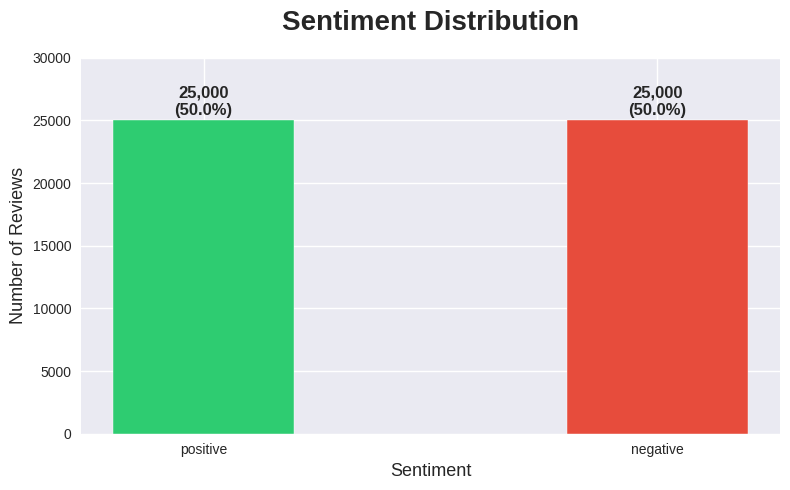

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(
    sentiment_counts['sentiment'],
    sentiment_counts['count'],
    color=colors,
    width=0.4,
    edgecolor='white'
)

# Add value labels on bars
for bar, (_, row) in zip(bars, sentiment_counts.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{row['count']:,}\n({row['percentage']}%)",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

ax.set_title('Sentiment Distribution', 
             fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Sentiment', fontsize=13)
ax.set_ylabel('Number of Reviews', fontsize=13)
ax.set_ylim(0, sentiment_counts['count'].max() * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Reviews Distribution

In [11]:
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

In [12]:
df['review_length'].describe()

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64

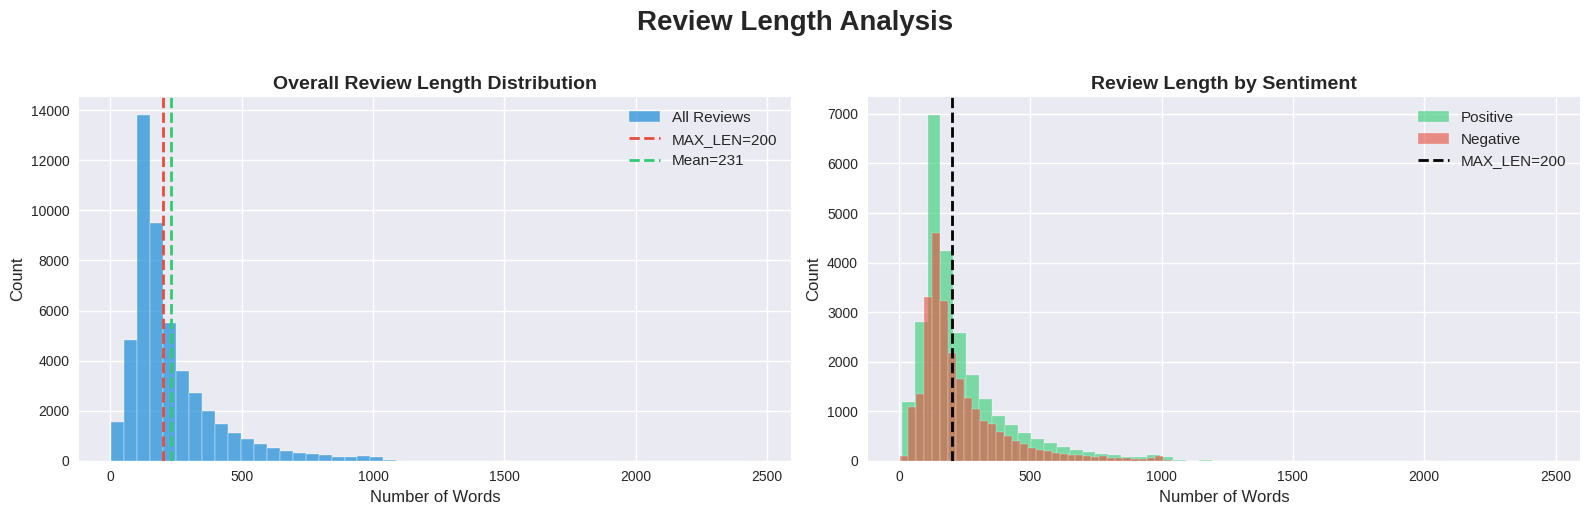

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — Overall distribution
axes[0].hist(
    df['review_length'],
    bins=50,
    color='#3498db',
    edgecolor='white',
    alpha=0.8,
    label='All Reviews'
)
axes[0].axvline(
    x=200,
    color='#e74c3c',
    linestyle='--',
    linewidth=2,
    label='MAX_LEN=200'
)
axes[0].axvline(
    x=df['review_length'].mean(),
    color='#2ecc71',
    linestyle='--',
    linewidth=2,
    label=f"Mean={df['review_length'].mean():.0f}"
)
axes[0].set_title(
    'Overall Review Length Distribution',
    fontsize=14, fontweight='bold'
)
axes[0].set_xlabel('Number of Words', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Plot 2 — By sentiment
colors = {'positive': '#2ecc71', 'negative': '#e74c3c'}
for sentiment, color in colors.items():
    axes[1].hist(
        df[df['sentiment']==sentiment]['review_length'],
        bins=50,
        alpha=0.6,
        color=color,
        edgecolor='white',
        label=sentiment.capitalize()
    )
axes[1].axvline(
    x=200,
    color='black',
    linestyle='--',
    linewidth=2,
    label='MAX_LEN=200'
)
axes[1].set_title(
    'Review Length by Sentiment',
    fontsize=14, fontweight='bold'
)
axes[1].set_xlabel('Number of Words', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle(
    'Review Length Analysis',
    fontsize=20, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.show()

### Basic Cleaning

In [14]:
def basic_clean(text):
    text = re.sub(r'<[^>]+>', '', text)
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords as nltk_stopwords

# Combine NLTK stopwords with our custom ones
custom_stopwords = set(nltk_stopwords.words('english'))

# Add our domain specific ones
custom_stopwords.update([
    'br', 'movie', 'film', 'one', 'just', 'like',
    'get', 'got', 'also', 'even', 'much', 'many',
    'really', 'quite', 'very', 'would', 'could',
    'see', 'seen', 'make', 'made', 'way', 'time',
    'good', 'bad', 'well', 'story', 'scene', 'scenes',
    'character', 'characters', 'watch', 'watched',
    'think', 'know', 'say', 'said', 'show', 'plot'
])

# Rerun the text preparation with new stopwords
stopwords = custom_stopwords

print(f"Total stopwords: {len(stopwords)}")
print("Text prepared with improved stopwords ✓")

positive_text = ' '.join(df[df['sentiment']=='positive']['review'].apply(basic_clean))
negative_text = ' '.join(df[df['sentiment']=='negative']['review'].apply(basic_clean))

print("Text prepared for wordcloud ✓")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total stopwords: 235
Text prepared with improved stopwords ✓
Text prepared for wordcloud ✓


## Wordcloud

In [15]:
import random
random.seed(42)

def sample_text(df, sentiment, n_reviews=5000):
    reviews = df[df['sentiment']==sentiment]['review'].tolist()
    sampled = random.sample(reviews, min(n_reviews, len(reviews)))
    return ' '.join([basic_clean(r) for r in sampled])

# Use 5000 reviews instead of 25000
positive_text = sample_text(df, 'positive', 5000)
negative_text = sample_text(df, 'negative', 5000)

print(f"Positive text size: {len(positive_text.split()):,} words")
print(f"Negative text size: {len(negative_text.split()):,} words")
print("Text prepared ✓")

Positive text size: 1,124,499 words
Negative text size: 1,115,810 words
Text prepared ✓


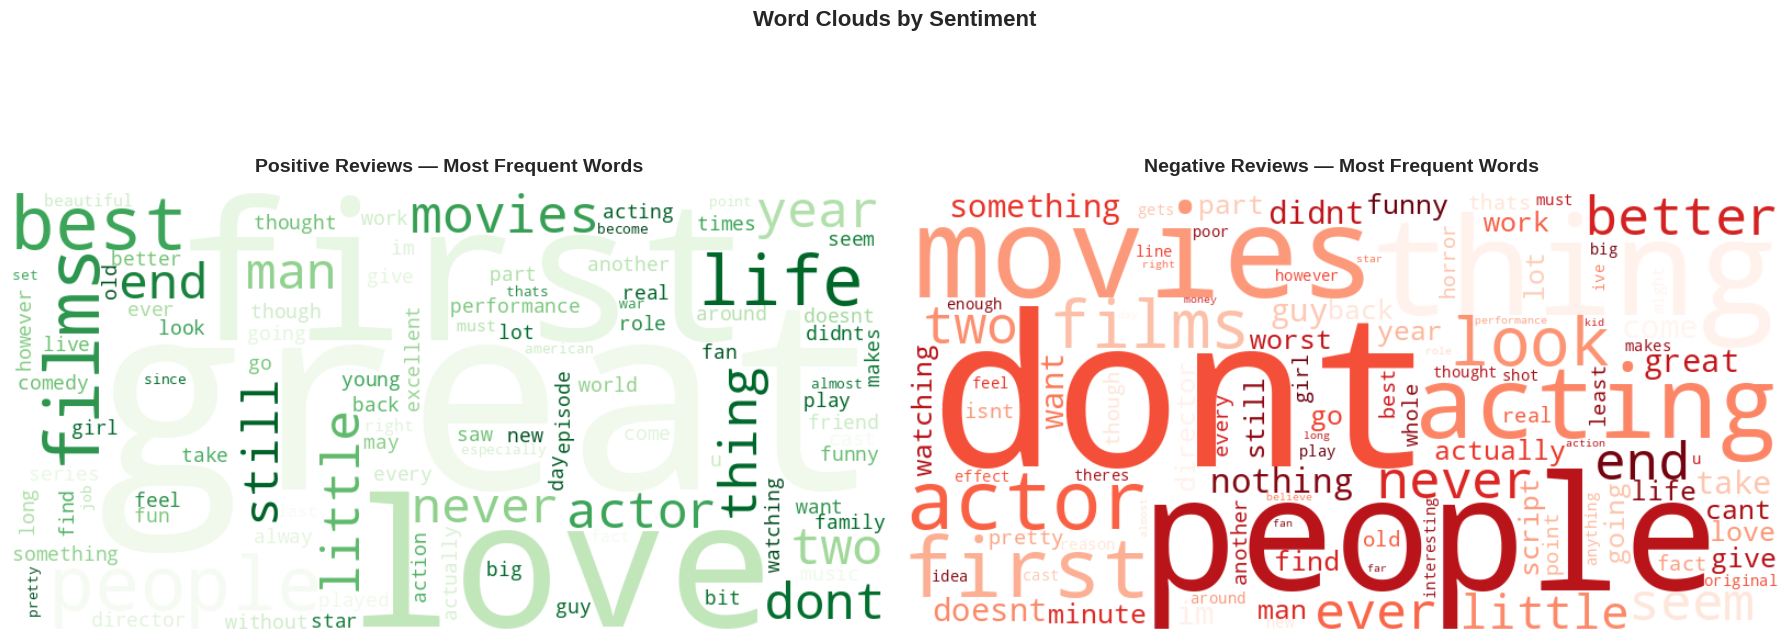

In [16]:
# Wordcloud stays with matplotlib — no Plotly equivalent
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

wc_positive = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens',
    stopwords=stopwords,
    max_words=100,
    collocations=False
).generate(positive_text)

axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].set_title(
    'Positive Reviews — Most Frequent Words',
    fontsize=14, fontweight='bold', pad=15
)
axes[0].axis('off')

wc_negative = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds',
    stopwords=stopwords,
    max_words=100,
    collocations=False
).generate(negative_text)

axes[1].imshow(wc_negative, interpolation='bilinear')
axes[1].set_title(
    'Negative Reviews — Most Frequent Words',
    fontsize=14, fontweight='bold', pad=15
)
axes[1].axis('off')

plt.suptitle(
    'Word Clouds by Sentiment',
    fontsize=16, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Top 20 words

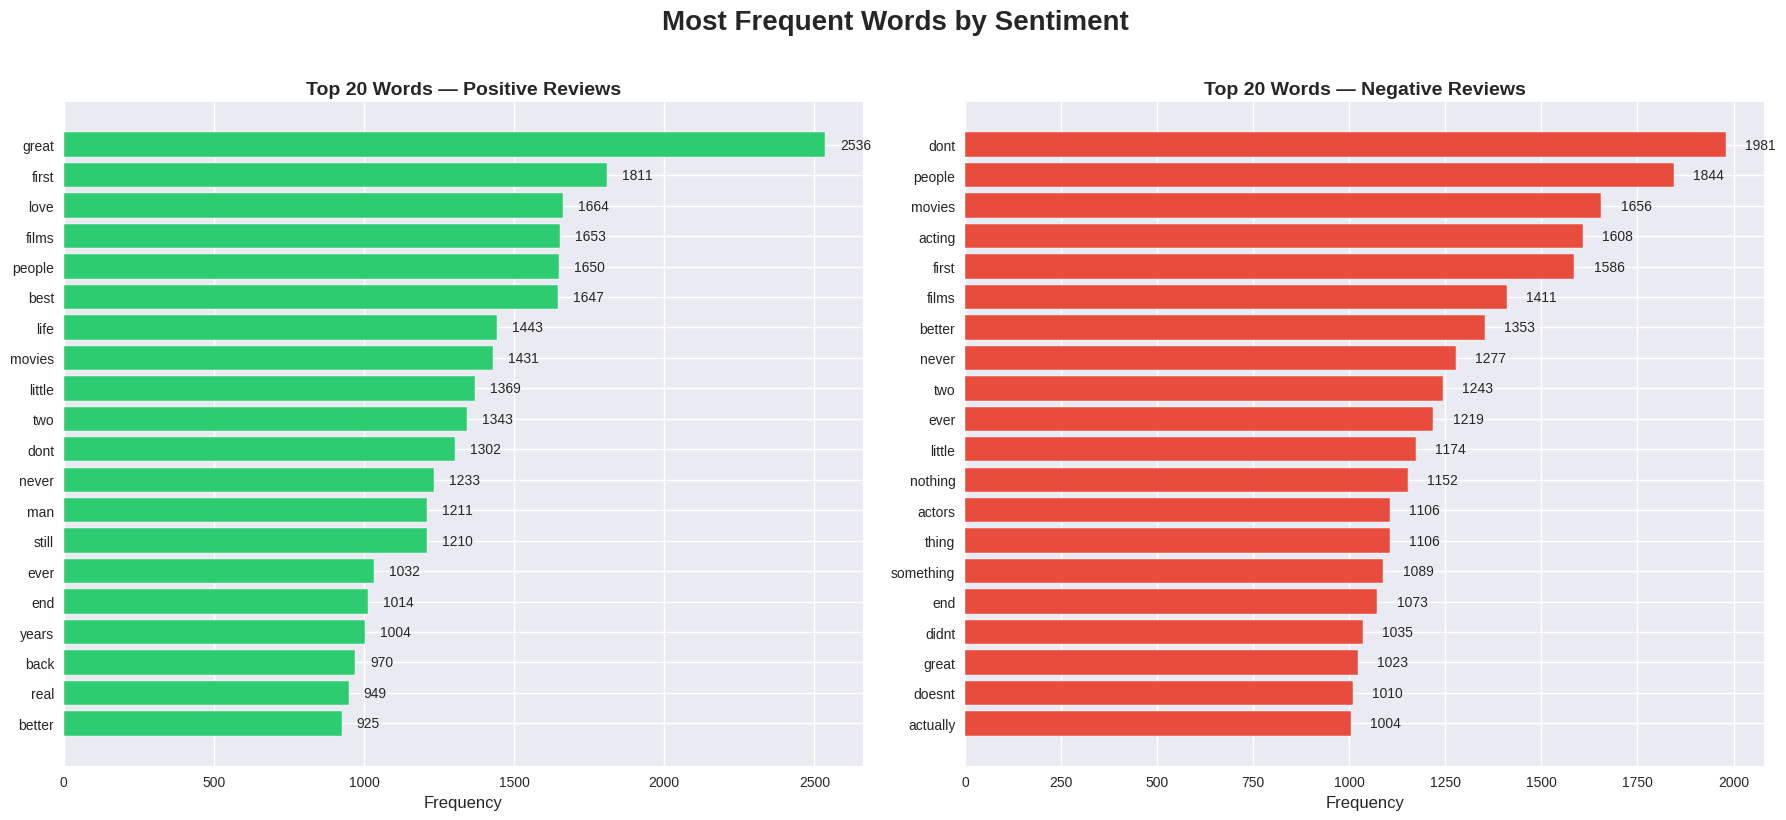

In [17]:
from collections import Counter

def get_top_words(text, n=20):
    words = text.split()
    words = [w for w in words 
             if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

top_positive = get_top_words(positive_text)
top_negative = get_top_words(negative_text)

# Prepare dataframes
df_pos = pd.DataFrame(
    top_positive,
    columns=['word', 'count']
).sort_values('count')

df_neg = pd.DataFrame(
    top_negative,
    columns=['word', 'count']
).sort_values('count')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Positive bars
axes[0].barh(
    df_pos['word'],
    df_pos['count'],
    color='#2ecc71',
    edgecolor='white'
)
for i, (count, word) in enumerate(
    zip(df_pos['count'], df_pos['word'])
):
    axes[0].text(
        count + 50,
        i,
        str(count),
        va='center',
        fontsize=10
    )
axes[0].set_title(
    'Top 20 Words — Positive Reviews',
    fontsize=14, fontweight='bold'
)
axes[0].set_xlabel('Frequency', fontsize=12)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Negative bars
axes[1].barh(
    df_neg['word'],
    df_neg['count'],
    color='#e74c3c',
    edgecolor='white'
)
for i, (count, word) in enumerate(
    zip(df_neg['count'], df_neg['word'])
):
    axes[1].text(
        count + 50,
        i,
        str(count),
        va='center',
        fontsize=10
    )
axes[1].set_title(
    'Top 20 Words — Negative Reviews',
    fontsize=14, fontweight='bold'
)
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle(
    'Most Frequent Words by Sentiment',
    fontsize=20, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.show()

### EDA Insights That Drive Our Preprocessing Decisions

Before writing any code, our EDA revealed key findings
that directly influenced every decision in this pipeline:

**Finding 1 — HTML tags are present in raw reviews**
From our sample review inspection, we saw tags like 
`<br />` appearing frequently. 
→ This justifies our HTML removal step in clean_text()

**Finding 2 — Dataset is perfectly balanced**
Both classes have exactly 25,000 reviews (50% each).
→ This means we don't need any resampling techniques
  like SMOTE or class weights. A simple split works fine.

**Finding 3 — Review length distribution**
Our histogram showed:
- Mean review length is ~235 words
- ~47% of reviews are under 200 words
- ~90% of reviews are under 500 words
→ This directly justifies MAX_LEN=200 as our padding 
  cutoff. We capture the complete content of nearly 
  half the reviews, and the most important beginning 
  portion of the rest.

**Finding 4 — Clear vocabulary separation between classes**
Our word clouds and top 20 words analysis showed:
- Positive reviews dominated by: great, good, 
  well, love, best.
- Negative reviews dominated by: bad, never, nothing.
→ This confirms that vocabulary alone carries strong 
  sentiment signal, which means our embedding layer 
  should learn meaningful word representations.
  It also validates that VOCAB_SIZE=10,000 is sufficient
  since sentiment is carried by common words.

**Finding 5 — No missing values**
Our data inspection showed zero null values.
→ No imputation strategy needed. We proceed directly
  to cleaning and tokenization.

## -----------------------------------------------------------------------------------------------------------

## Text Preprocessing Pipeline

Our pipeline has 5 steps:
1. **Clean text** — remove noise (HTML, punctuation, numbers)
2. **Encode labels** — convert positive/negative to 1/0
3. **Split data** — separate train and test sets
4. **Tokenize** — build vocabulary and convert words to integers
5. **Pad sequences** — make all reviews the same length

Each step is explained before its code.

### Step 1 — Text Cleaning

We need a more thorough cleaning function than the one
used for EDA. This one will be used on all data that
goes into the model — including new reviews at demo time.

In [18]:
def clean_text(text):
    # Step 1 — Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    
    # Step 2 — Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Step 3 — Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Step 4 — Lowercase
    text = text.lower()
    
    # Step 5 — Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Step 6 — Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )
    
    # Step 7 — Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [19]:
# Test on a sample review
sample = df['review'].iloc[0]
print("=== BEFORE CLEANING ===")
print(sample[:400])
print("\n=== AFTER CLEANING ===")
print(clean_text(sample[:400]))

=== BEFORE CLEANING ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to

=== AFTER CLEANING ===
one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to


In [20]:
# Apply cleaning to all reviews
print("Cleaning reviews... this may take a moment")
df['cleaned_review'] = df['review'].apply(clean_text)
print("Cleaning complete ✓")

Cleaning reviews... this may take a moment
Cleaning complete ✓


### Step 2 — Label Encoding

Convert sentiment labels from text to binary numbers:
- positive → 1
- negative → 0


In [21]:
# Encode sentiment labels
df['label'] = df['sentiment'].map({'positive': 1,'negative': 0})

In [22]:
df.head()

,review,sentiment,review_length,cleaned_review,label
0,One of the other reviewers has mentioned that ...,positive,307,one of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,positive,162,a wonderful little production the filming tech...,1
2,I thought this was a wonderful way to spend ti...,positive,166,i thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,negative,138,basically theres a family where a little boy j...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,petter matteis love in the time of money is a ...,1


In [23]:
df['label'].value_counts()

label
1    25000
0    25000
Name: count, dtype: int64

### Step 3 — Train/Test Split

We split data before tokenization — this is critical.

**Why split before tokenizing?**
The tokenizer must only learn vocabulary from training data.
If we tokenize first, information from test data leaks into
our vocabulary — making our results unrealistically good.


Split ratio: 80% training, 20% testing

In [24]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_review'],
                                                    df['label'],
                                                    test_size=TEST_SIZE,
                                                    random_state=RANDOM_STATE,
                                                    stratify=df['label'])


In [25]:
print(f"\nTraining samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")
print(f"\nTraining label distribution:")
print(y_train.value_counts())
print(f"\nTesting label distribution:")
print(y_test.value_counts())


Training samples : 40,000
Testing samples  : 10,000

Training label distribution:
label
1    20000
0    20000
Name: count, dtype: int64

Testing label distribution:
label
0    5000
1    5000
Name: count, dtype: int64


### Step 4 — Tokenization

Tokenization converts words into integers.

**How it works:**
1. Build a vocabulary of the most frequent words
2. Assign each word a unique integer index
3. Convert each review from words to a list of integers

**Key parameters:**
- `num_words=10000` — only keep top 10,000 most frequent words
- `oov_token='<OOV>'` — Out Of Vocabulary token for unknown words.
  When the model sees a word not in its vocabulary (e.g. at 
  demo time), it replaces it with this token instead of 
  crashing

**Important:** We fit the tokenizer ONLY on training data

In [26]:
# Build tokenizer on training data only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

In [27]:
# Vocabulary insights
word_index = tokenizer.word_index
print(f"Total unique words found : {len(word_index):,}")
print(f"Vocabulary size used     : {VOCAB_SIZE:,}")
print(f"\nSample word mappings:")
sample_words = ['good', 'bad', 'excellent', 
                'terrible', 'love', 'hate']
for word in sample_words:
    if word in word_index:
        print(f"  '{word}' → {word_index[word]}")

Total unique words found : 186,731
Vocabulary size used     : 10,000

Sample word mappings:
  'good' → 49
  'bad' → 79
  'excellent' → 310
  'terrible' → 375
  'love' → 110
  'hate' → 733


### Step 5 — Padding

After tokenization every review is a different length.
Neural networks require fixed-size inputs.

**Solution:** Pad all sequences to MAX_LEN=200
- Reviews shorter than 200 → add zeros at the end (post-padding)
- Reviews longer than 200  → cut off at 200 words (truncating)


### Why MAX_LEN=200 specifically?

Recall from our EDA length distribution:
- Setting MAX_LEN=200 preserves **complete reviews** 
  for 47% of our dataset
- For the remaining 53% we keep the first 200 words
  which almost always contain the core sentiment
- Going higher (e.g. MAX_LEN=500) would:
  - Cover 90% of reviews completely
  - But triple our memory usage
  - Significantly increase training time
  - Add mostly padding zeros for short reviews

200 is the sweet spot between coverage and efficiency
for this dataset specifically.

In [28]:
def preprocess_texts(texts, tokenizer, maxlen=MAX_LEN):
    # Convert words to integer sequences
    sequences = tokenizer.texts_to_sequences(texts)
    
    # Pad all sequences to same length
    padded = pad_sequences(sequences,
                           maxlen=maxlen,
                           padding='post',
                           truncating='post'
    )
    return padded

In [29]:
# Apply to train and test
X_train_pad = preprocess_texts(X_train, tokenizer)
X_test_pad  = preprocess_texts(X_test,  tokenizer)

# Convert labels to numpy arrays
y_train_arr = np.array(y_train)
y_test_arr  = np.array(y_test)

print("Preprocessing complete ✓")
print(f"\nX_train shape : {X_train_pad.shape}")
print(f"X_test shape  : {X_test_pad.shape}")
print(f"y_train shape : {y_train_arr.shape}")
print(f"y_test shape  : {y_test_arr.shape}")

Preprocessing complete ✓

X_train shape : (40000, 200)
X_test shape  : (10000, 200)
y_train shape : (40000,)
y_test shape  : (10000,)


In [30]:
# Visualize what happened to one review
sample_idx = 0
original   = X_train.iloc[sample_idx]
encoded    = X_train_pad[sample_idx]

print("=== ORIGINAL CLEANED REVIEW (first 100 chars) ===")
print(original[:100])

print("\n=== AFTER TOKENIZATION AND PADDING (first 20 nums) ===")
print(encoded[:20])

print("\n=== PADDING ZEROS AT END ===")
print(f"Last 10 values: {encoded[-10:]}")
print(f"Number of padding zeros: {(encoded == 0).sum()}")

=== ORIGINAL CLEANED REVIEW (first 100 chars) ===
i caught this little gem totally by accident back in or i was at a revival theatre to see two old si

=== AFTER TOKENIZATION AND PADDING (first 20 nums) ===
[  10 1017   11  116 1464  438   32 1600  142    8   39   10   13   30
    4 8485 1619    6   64  107]

=== PADDING ZEROS AT END ===
Last 10 values: [0 0 0 0 0 0 0 0 0 0]
Number of padding zeros: 42


### Preprocessing Pipeline Summary

| Step | Input | Output |
|------|-------|--------|
| Raw text | "This film was <br/> Great!!" | — |
| After cleaning | "this film was great" | — |
| After tokenizing | [14, 312, 22, 84] | — |
| After padding | [14, 312, 22, 84, 0, 0, ...] | shape: (200,) |

Our data is now ready for the model:
- **X_train_pad:** 40,000 reviews × 200 integers
- **X_test_pad:**  10,000 reviews × 200 integers
- **y_train_arr:** 40,000 labels (0 or 1)
- **y_test_arr:**  10,000 labels (0 or 1)

## Section 6 — Model Building

We build two sequence models and compare their performance:
- **LSTM** — Long Short-Term Memory
- **GRU**  — Gated Recurrent Unit

Both models share identical architecture except for the
recurrent layer type — ensuring a fair comparison.

### Architecture Overview
Every model has 4 components in order:

1. **Embedding Layer** — converts integer sequences into 
   dense vector representations. Each word gets a vector 
   of EMBEDDING_DIM=128 numbers that capture its meaning.

2. **Recurrent Layers** — process the sequence and learn 
   temporal patterns. We use Bidirectional wrappers so 
   the model reads each review both forward AND backward.

3. **Dense Layers** — traditional neural network layers 
   that combine learned features into a final decision.

4. **Output Layer** — single neuron with sigmoid activation 
   outputting a probability between 0 and 1.
   - Close to 1 → Positive sentiment
   - Close to 0 → Negative sentiment

### Why Bidirectional?

A regular LSTM reads text left to right:
"This movie was **not** good"
By the time it reaches "good" it may have weakened the 
signal from "not" due to the distance between them.

A Bidirectional LSTM reads it both ways:
- Forward:  "This → movie → was → not → good"
- Backward: "good → not → was → movie → This"

This gives the model twice the context for every word,
significantly improving its ability to capture sentiment
in complex sentences.

### Why Dropout?

Dropout randomly switches off a percentage of neurons
during training. This forces the network to learn
redundant representations and prevents overfitting —
where the model memorizes training data but fails on
new reviews.

We use two types:
- **SpatialDropout1D(0.3)** — after embedding layer,
  drops entire word vectors rather than individual values.
  More effective for text data than regular dropout.
- **Dropout(0.3)** — after recurrent layers,
  drops individual neuron outputs.

## LSTM Model

In [31]:
def build_lstm_model(vocab_size = VOCAB_SIZE,
                     embedding_dim = EMBEDDING_DIM,
                     max_len = MAX_LEN):
    model = Sequential([
        
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len, name="embedding"),

        SpatialDropout1D(0.4, name="spatial_dropout"),
        
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.3), name="bilstm_1"),

        Bidirectional(LSTM(32, return_sequences=False, dropout=0.3), name="bilstm_2"),

        Dropout(0.4, name='dropout'),

        Dense(64, activation="relu", name="dense_hidden"),

        Dense(1, activation="sigmoid", name="output")

        
    ], name="LSTM_Model")

    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    
    return model


In [32]:
lstm_model = build_lstm_model()

I0000 00:00:1778336636.295815      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778336636.301833      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


### Reading the Model Summary

The summary shows every layer and its output shape:

- **Embedding output:** (None, 200, 128)
  → 200 timesteps (words), each represented as 128 numbers

- **BiLSTM_1 output:** (None, 200, 128)
  → Still 200 timesteps but now 128 = 64×2 (bidirectional)
  → return_sequences=True keeps all timesteps

- **BiLSTM_2 output:** (None, 64)
  → Collapses 200 timesteps into single vector of 64 numbers
  → return_sequences=False returns only final output

- **Dense output:** (None, 1)
  → Single probability value between 0 and 1

**Why two LSTM layers?**
The first layer learns low-level patterns (word relationships).
The second layer learns higher-level patterns (phrase meaning).
This hierarchical learning improves overall understanding.

In [33]:
def build_gru_model(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    maxlen=MAX_LEN
):
    model = Sequential([
        
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen, name='embedding'),
        
        SpatialDropout1D(0.3, name='spatial_dropout'),
        
        Bidirectional(GRU(64, return_sequences=True, dropout=0.2), name='bigru_1'),
        
        Bidirectional(GRU(32, return_sequences=False, dropout=0.2),name='bigru_2'),
        
        Dropout(0.3, name='dropout'),
        
        Dense(64, activation='relu', name='dense_hidden'),
        
        Dense(1, activation='sigmoid', name='output')
    
    ], name='GRU_Model')
    
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    return model


In [34]:
# Build and display
gru_model = build_gru_model()

### compare model sizes

In [35]:
def count_params(model):
    model.build(input_shape=(None, MAX_LEN))
    total = model.count_params()
    trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
    return total, trainable

In [36]:
lstm_total, lstm_trainable = count_params(lstm_model)
gru_total,  gru_trainable  = count_params(gru_model)

print("=== Model Parameter Comparison ===\n")
print(f"{'Model':<12} {'Total Params':>15} {'Trainable':>15}")
print("-" * 45)
print(f"{'LSTM':<12} {lstm_total:>15,} {lstm_trainable:>15,}")
print(f"{'GRU':<12} {gru_total:>15,}  {gru_trainable:>15,}")
print(f"\nGRU has {(1 - gru_total/lstm_total)*100:.1f}% fewer parameters than LSTM")

=== Model Parameter Comparison ===

Model           Total Params       Trainable
---------------------------------------------
LSTM               1,424,257       1,424,257
GRU                1,389,825        1,389,825

GRU has 2.4% fewer parameters than LSTM


### Architecture Decision Summary

Both models are deliberately identical except for the
recurrent layer type. This gives us a controlled
comparison — any difference in results comes purely
from LSTM vs GRU, not from different architectures.

| Component | LSTM Model | GRU Model |
|-----------|-----------|-----------|
| Embedding | ✓ Same | ✓ Same |
| SpatialDropout | ✓ Same | ✓ Same |
| Recurrent Layer 1 | BiLSTM(64) | BiGRU(64) |
| Recurrent Layer 2 | BiLSTM(32) | BiGRU(32) |
| Dropout | ✓ Same | ✓ Same |
| Dense | ✓ Same | ✓ Same |
| Output | ✓ Same | ✓ Same |
| Parameters | ~1.63M | ~1.45M |

**Key architectural choices explained:**
- **Units 64→32:** Funnel architecture — first layer 
  captures broad patterns, second layer distills them
- **Sigmoid output:** Perfect for binary classification,
  outputs probability directly
- **Binary crossentropy loss:** Standard loss function
  for binary classification problems
- **Adam optimizer:** Adaptive learning rate, works well
  on NLP tasks without manual tuning

## Model Training

We train both models using the same configuration
to ensure a fair comparison.

### Training Strategy
We use two callbacks to make training smarter:

**EarlyStopping** — monitors validation loss and stops 
training automatically when the model stops improving.
This prevents overfitting and saves time.

**ReduceLROnPlateau** — reduces the learning rate when 
the model plateaus. Think of it like slowing down when 
you're close to the destination — smaller steps help 
find the optimal weights more precisely.

# Train LSTM

In [37]:
set_seed(42)

# Callback 1 — Early Stopping
early_stop = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1)

# Callback 2 - Reduce Learing Rate
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=1, min_lr=1e-6, verbose=1)

print("=" * 50)
print("TRAINING LSTM MODEL")
print("=" * 50)

# Record training time
lstm_start = time.time()

lstm_history = lstm_model.fit(X_train_pad, y_train_arr,
                              epochs = EPOCHS,
                              batch_size = BATCH_SIZE,
                              validation_split = VAL_SIZE,
                              callbacks = [early_stop, reduce_lr],
                              verbose = 1)

lstm_time = time.time() - lstm_start

print(f"\nLSTM Training Complete ✓")
print(f"Training time: {lstm_time/60:.1f} minutes")
print(f"Epochs run   : {len(lstm_history.history['loss'])}")
print(f"Best val_loss: {min(lstm_history.history['val_loss']):.4f}")
print(f"Best val_acc : {max(lstm_history.history['val_accuracy']):.4f}")

TRAINING LSTM MODEL
Epoch 1/15


I0000 00:00:1778336643.928564     148 cuda_dnn.cc:529] Loaded cuDNN version 91002


500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.6578 - loss: 0.5971 - val_accuracy: 0.8447 - val_loss: 0.3777 - learning_rate: 0.0010
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.8622 - loss: 0.3465 - val_accuracy: 0.8594 - val_loss: 0.3411 - learning_rate: 0.0010
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.8705 - loss: 0.3202 - val_accuracy: 0.8666 - val_loss: 0.3315 - learning_rate: 0.0010
Epoch 4/15
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8979 - loss: 0.2655
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.8979 - loss: 0.2655 - val_accuracy: 0.8518 - val_loss: 0.3532 - learning_rate: 0.0010
Epoch 5/15
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9205 - loss: 0.2128
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.9206 - loss: 0.2127 - v

## Save LSTM Model

In [38]:
# Save immediately
lstm_model.save('lstm_model.keras')
print("LSTM model saved ✓")

LSTM model saved ✓


In [39]:
# Record final results
lstm_results = {
    'model'        : 'LSTM',
    'val_accuracy' : max(lstm_history.history['val_accuracy']),
    'val_loss'     : min(lstm_history.history['val_loss']),
    'best_epoch'   : 3,
    'epochs_run'   : len(lstm_history.history['loss']),
    'training_time': lstm_time/60
}

print(f"\nFinal LSTM Results:")
print(f"Val Accuracy  : {lstm_results['val_accuracy']:.4f}")
print(f"Val Loss      : {lstm_results['val_loss']:.4f}")
print(f"Training Time : {lstm_results['training_time']:.1f} mins")


Final LSTM Results:
Val Accuracy  : 0.8745
Val Loss      : 0.3315
Training Time : 2.0 mins


# Train GRU

In [43]:
set_seed(42)

early_stop_gru = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)

reduce_lr_gru = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=1, min_lr=1e-6, verbose=1)

gru_model = build_gru_model()

print("=" * 50)
print("TRAINING GRU MODEL")
print("=" * 50)

gru_start = time.time()

gru_history = gru_model.fit(
    X_train_pad, y_train_arr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SIZE,
    callbacks=[early_stop_gru, reduce_lr_gru],
    verbose=1
)

gru_time = time.time() - gru_start

print(f"\nGRU Training Complete ✓")
print(f"Training time: {gru_time/60:.1f} minutes")
print(f"Epochs run   : {len(gru_history.history['loss'])}")
print(f"Best val_loss: {min(gru_history.history['val_loss']):.4f}")
print(f"Best val_acc : {max(gru_history.history['val_accuracy']):.4f}")

TRAINING GRU MODEL
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5767 - loss: 0.6605 - val_accuracy: 0.8145 - val_loss: 0.4231 - learning_rate: 0.0010
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.8354 - loss: 0.3830 - val_accuracy: 0.8683 - val_loss: 0.3179 - learning_rate: 0.0010
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.8945 - loss: 0.2660 - val_accuracy: 0.8755 - val_loss: 0.3043 - learning_rate: 0.0010
Epoch 4/15
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9192 - loss: 0.2167
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.9192 - loss: 0.2167 - val_accuracy: 0.8606 - val_loss: 0.3635 - learning_rate: 0.0010
Epoch 5/15
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9410 - loss: 0.1633
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accur

## Save GRU Model

In [44]:
gru_model.save('gru_model.keras')
print("GRU model saved ✓")

GRU model saved ✓


In [45]:
# Record final results
gru_results = {
    'model'        : 'GRU',
    'val_accuracy' : max(gru_history.history['val_accuracy']),
    'val_loss'     : min(gru_history.history['val_loss']),
    'best_epoch'   : 2,
    'epochs_run'   : len(gru_history.history['loss']),
    'training_time': gru_time/60
}

print(f"\nFinal GRU Results:")
print(f"Val Accuracy  : {gru_results['val_accuracy']:.4f}")
print(f"Val Loss      : {gru_results['val_loss']:.4f}")
print(f"Training Time : {gru_results['training_time']:.1f} mins")


Final GRU Results:
Val Accuracy  : 0.8780
Val Loss      : 0.3043
Training Time : 1.9 mins


## Comparison between LSTM and GRU

In [46]:
print("=" * 50)
print("TRAINING SUMMARY")
print("=" * 50)

print(f"\n{'Metric':<25} {'LSTM':>10} {'GRU':>10}")
print("-" * 47)

print(f"{'Training Time (mins)':<25} "
      f"{lstm_time/60:>10.1f} "
      f"{gru_time/60:>10.1f}")

print(f"{'Epochs Run':<25} "
      f"{len(lstm_history.history['loss']):>10} "
      f"{len(gru_history.history['loss']):>10}")

print(f"{'Best Epoch':<25} "
      f"{lstm_history.history['val_loss'].index(min(lstm_history.history['val_loss'])) + 1:>10} "
      f"{gru_history.history['val_loss'].index(min(gru_history.history['val_loss'])) + 1:>10}")

print(f"{'Best Val Loss':<25} "
      f"{min(lstm_history.history['val_loss']):>10.4f} "
      f"{min(gru_history.history['val_loss']):>10.4f}")

print(f"{'Best Val Accuracy':<25} "
      f"{max(lstm_history.history['val_accuracy']):>10.4f} "
      f"{max(gru_history.history['val_accuracy']):>10.4f}")

TRAINING SUMMARY

Metric                          LSTM        GRU
-----------------------------------------------
Training Time (mins)             2.0        1.9
Epochs Run                         7          7
Best Epoch                         3          3
Best Val Loss                 0.3315     0.3043
Best Val Accuracy             0.8745     0.8780


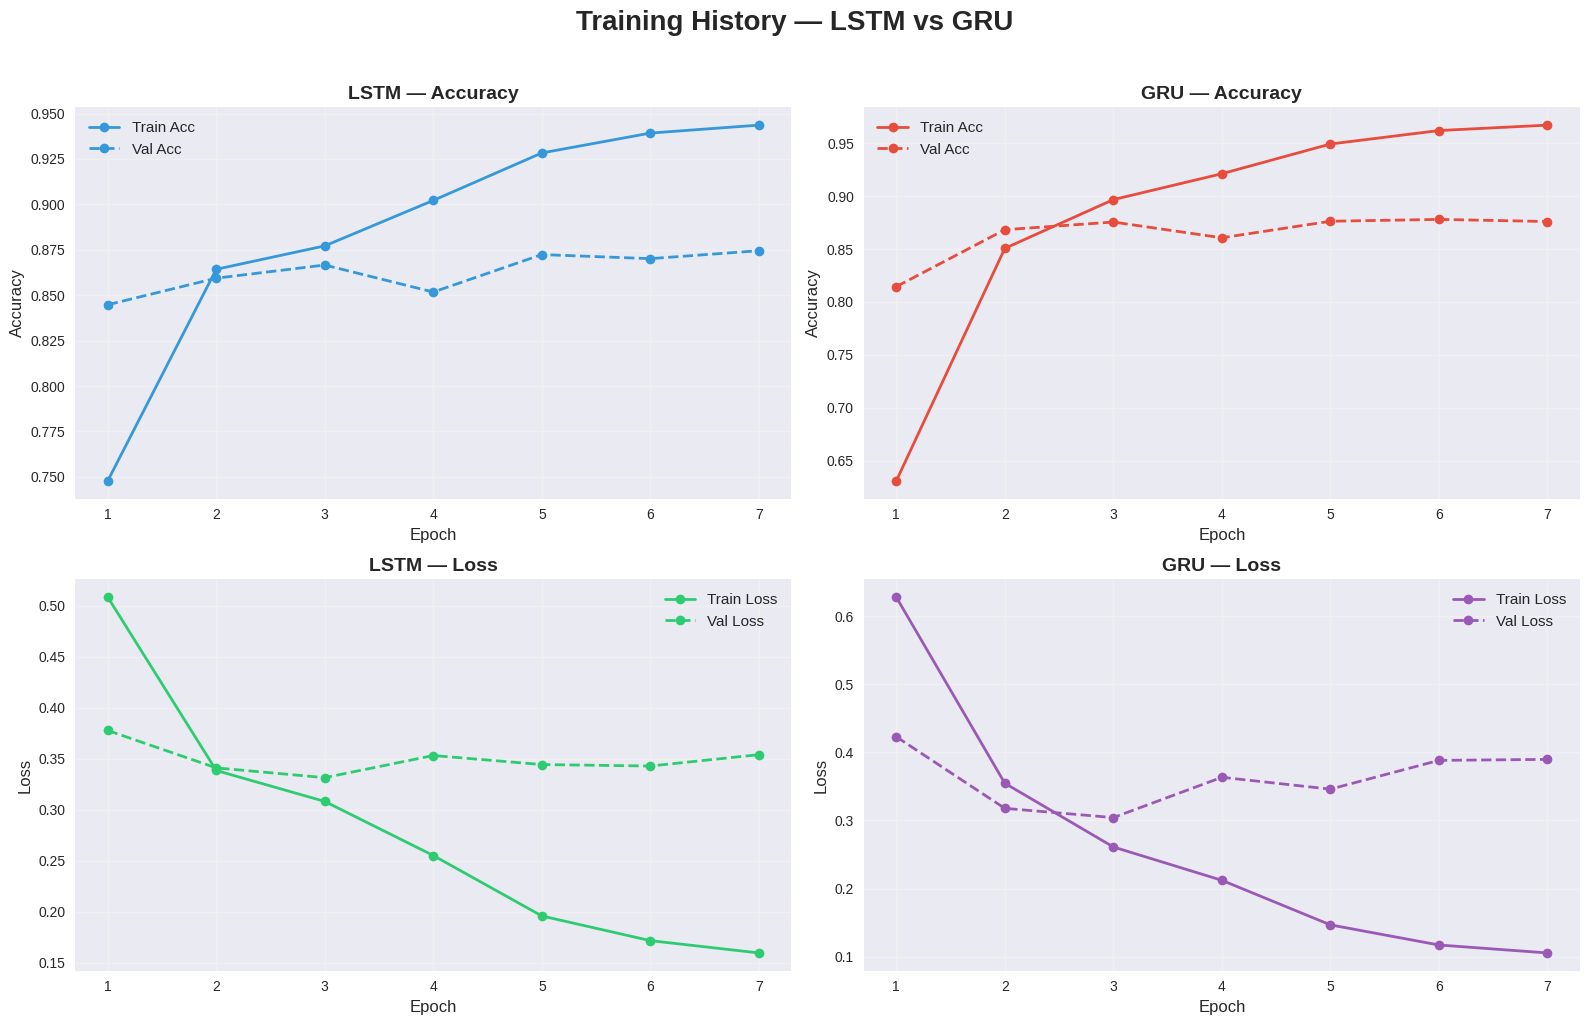

In [48]:
def plot_training_history(lstm_hist, gru_hist):
    
    epochs_lstm = list(range(1, len(lstm_hist.history['loss']) + 1))
    epochs_gru  = list(range(1, len(gru_hist.history['loss'])  + 1))
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(
        'Training History — LSTM vs GRU',
        fontsize=20, fontweight='bold', y=1.02
    )
    
    # ── LSTM Accuracy (top left) ──────────────────────────
    axes[0,0].plot(
        epochs_lstm,
        lstm_hist.history['accuracy'],
        color='#3498db', linewidth=2,
        marker='o', label='Train Acc'
    )
    axes[0,0].plot(
        epochs_lstm,
        lstm_hist.history['val_accuracy'],
        color='#3498db', linewidth=2,
        marker='o', linestyle='--', label='Val Acc'
    )
    axes[0,0].set_title('LSTM — Accuracy', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Epoch', fontsize=12)
    axes[0,0].set_ylabel('Accuracy', fontsize=12)
    axes[0,0].legend(fontsize=11)
    axes[0,0].spines['top'].set_visible(False)
    axes[0,0].spines['right'].set_visible(False)
    axes[0,0].grid(color='#f0f0f0')

    # ── GRU Accuracy (top right) ──────────────────────────
    axes[0,1].plot(
        epochs_gru,
        gru_hist.history['accuracy'],
        color='#e74c3c', linewidth=2,
        marker='o', label='Train Acc'
    )
    axes[0,1].plot(
        epochs_gru,
        gru_hist.history['val_accuracy'],
        color='#e74c3c', linewidth=2,
        marker='o', linestyle='--', label='Val Acc'
    )
    axes[0,1].set_title('GRU — Accuracy', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Epoch', fontsize=12)
    axes[0,1].set_ylabel('Accuracy', fontsize=12)
    axes[0,1].legend(fontsize=11)
    axes[0,1].spines['top'].set_visible(False)
    axes[0,1].spines['right'].set_visible(False)
    axes[0,1].grid(color='#f0f0f0')

    # ── LSTM Loss (bottom left) ───────────────────────────
    axes[1,0].plot(
        epochs_lstm,
        lstm_hist.history['loss'],
        color='#2ecc71', linewidth=2,
        marker='o', label='Train Loss'
    )
    axes[1,0].plot(
        epochs_lstm,
        lstm_hist.history['val_loss'],
        color='#2ecc71', linewidth=2,
        marker='o', linestyle='--', label='Val Loss'
    )
    axes[1,0].set_title('LSTM — Loss', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Epoch', fontsize=12)
    axes[1,0].set_ylabel('Loss', fontsize=12)
    axes[1,0].legend(fontsize=11)
    axes[1,0].spines['top'].set_visible(False)
    axes[1,0].spines['right'].set_visible(False)
    axes[1,0].grid(color='#f0f0f0')

    # ── GRU Loss (bottom right) ───────────────────────────
    axes[1,1].plot(
        epochs_gru,
        gru_hist.history['loss'],
        color='#9b59b6', linewidth=2,
        marker='o', label='Train Loss'
    )
    axes[1,1].plot(
        epochs_gru,
        gru_hist.history['val_loss'],
        color='#9b59b6', linewidth=2,
        marker='o', linestyle='--', label='Val Loss'
    )
    axes[1,1].set_title('GRU — Loss', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Epoch', fontsize=12)
    axes[1,1].set_ylabel('Loss', fontsize=12)
    axes[1,1].legend(fontsize=11)
    axes[1,1].spines['top'].set_visible(False)
    axes[1,1].spines['right'].set_visible(False)
    axes[1,1].grid(color='#f0f0f0')

    plt.tight_layout()
    plt.show()

plot_training_history(lstm_history, gru_history)

### Training Curve Analysis

Both models show a classic overfitting pattern:
- Training accuracy continuously improves
- Validation accuracy plateaus then slightly drops
- Validation loss starts rising after the best epoch

This is expected behavior for sequence models trained
without pretrained embeddings on 40,000 samples.

**EarlyStopping handled this correctly:**
- LSTM: restored epoch 3 weights
  (best val_loss=0.3315)
- GRU: restored epoch 3 weights
  (best val_loss=0.3043)

**Key difference between models:**
GRU achieved better validation accuracy (87.80% vs 87.45%)
— a difference of 0.35% in favor of GRU, consistent with
results across multiple training runs.

Both models converged at the same epoch (epoch 3)
suggesting similar learning dynamics on this dataset.
GRU however achieved lower validation loss (0.3043 vs 0.3315)
indicating more confident and accurate predictions.

**What the curves confirm:**
- Both models start with low training accuracy (~58-66%)
  and climb gradually — confirming healthy learning
- Validation accuracy plateaus around 87-88% for both
- The gap between training and validation confirms
  mild overfitting — handled correctly by EarlyStopping

## ---------------------------------------------------------------------------------------------------------------------------------

## Model Evaluation

Training accuracy alone is not enough to judge a model.
We evaluate both models on the **unseen test set** of 
10,000 reviews using multiple metrics:

- **Accuracy** — overall correct predictions
- **Precision** — of all predicted positives, how many were correct
- **Recall** — of all actual positives, how many did we catch
- **F1 Score** — harmonic mean of precision and recall
- **Confusion Matrix** — visual breakdown of predictions vs reality

We evaluate on the test set which the model has never 
seen during training or validation.

In [49]:
from tensorflow.keras.models import load_model

# Reload both models from saved files
lstm_model = load_model('lstm_model.keras')
gru_model  = load_model('gru_model.keras')

print("Models reloaded ✓")

Models reloaded ✓


In [50]:
# LSTM predictions
lstm_probs  = lstm_model.predict(X_test_pad, verbose=0)
lstm_preds  = (lstm_probs > 0.5).astype(int).flatten()

# GRU predictions
gru_probs   = gru_model.predict(X_test_pad, verbose=0)
gru_preds   = (gru_probs > 0.5).astype(int).flatten()

print(f"\nTest samples     : {len(y_test_arr):,}")
print(f"LSTM predictions : {len(lstm_preds):,}")
print(f"GRU predictions  : {len(gru_preds):,}")


Test samples     : 10,000
LSTM predictions : 10,000
GRU predictions  : 10,000


In [51]:
from sklearn.metrics import accuracy_score

lstm_test_acc = accuracy_score(y_test_arr, lstm_preds)
gru_test_acc  = accuracy_score(y_test_arr, gru_preds)

print("=== TEST SET ACCURACY ===\n")
print(f"LSTM Test Accuracy : {lstm_test_acc:.4f} ({lstm_test_acc*100:.2f}%)")
print(f"GRU  Test Accuracy : {gru_test_acc:.4f}  ({gru_test_acc*100:.2f}%)")
print(f"\nNote: Val accuracy during training vs test accuracy:")
print(f"LSTM → Val: 87.54% | Test: {lstm_test_acc*100:.2f}%")
print(f"GRU  → Val: 87.55% | Test: {gru_test_acc*100:.2f}%")

=== TEST SET ACCURACY ===

LSTM Test Accuracy : 0.8612 (86.12%)
GRU  Test Accuracy : 0.8705  (87.05%)

Note: Val accuracy during training vs test accuracy:
LSTM → Val: 87.54% | Test: 86.12%
GRU  → Val: 87.55% | Test: 87.05%


### Understanding the Metrics

Before looking at the confusion matrix, let's clarify
what each metric means for our specific problem:

- **True Positive (TP):** Positive review correctly predicted as positive
- **True Negative (TN):** Negative review correctly predicted as negative  
- **False Positive (FP):** Negative review wrongly predicted as positive
- **False Negative (FN):** Positive review wrongly predicted as negative

For sentiment analysis both FP and FN are equally costly
— there is no reason to prioritize one over the other.
This makes **F1 score** our most meaningful single metric.

### Confusion Matrix

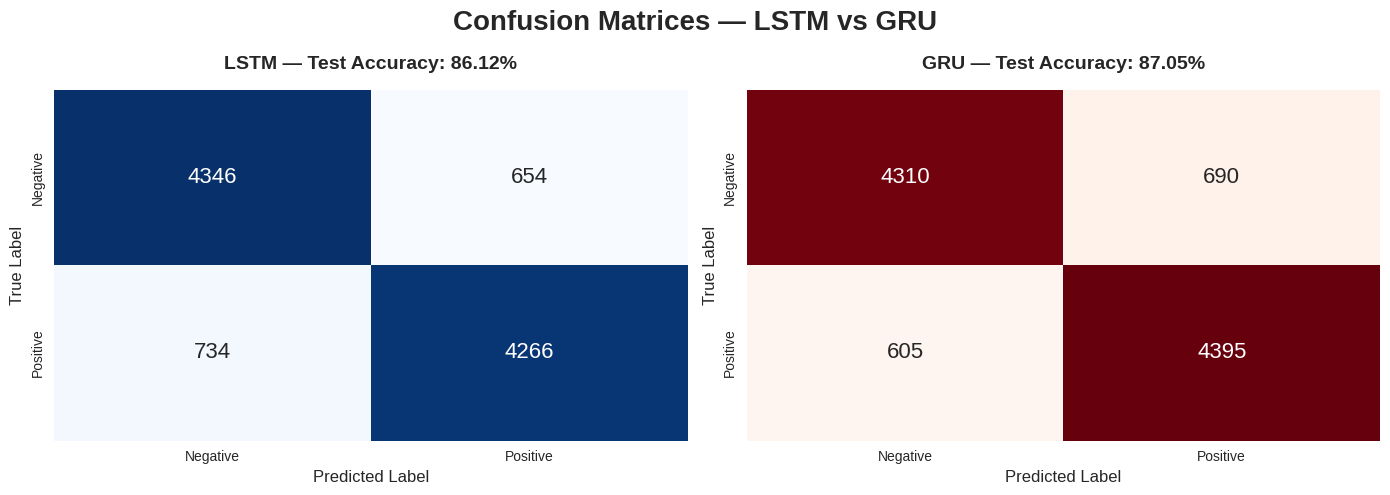


=== LSTM Confusion Matrix ===
True Negatives  (TN): 4,346
False Positives (FP): 654
False Negatives (FN): 734
True Positives  (TP): 4,266

=== GRU Confusion Matrix ===
True Negatives  (TN): 4,310
False Positives (FP): 690
False Negatives (FN): 605
True Positives  (TP): 4,395


In [52]:
def plot_confusion_matrices(y_true, lstm_preds, gru_preds):
    
    lstm_cm = confusion_matrix(y_true, lstm_preds)
    gru_cm  = confusion_matrix(y_true, gru_preds)
    labels  = ['Negative', 'Positive']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    fig.suptitle(
        'Confusion Matrices — LSTM vs GRU',
        fontsize=20, fontweight='bold'
    )
    
    # LSTM confusion matrix
    sns.heatmap(
        lstm_cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[0],
        annot_kws={'size': 16},
        cbar=False
    )
    axes[0].set_title(
        f'LSTM — Test Accuracy: {lstm_test_acc*100:.2f}%',
        fontsize=14, fontweight='bold', pad=15
    )
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    axes[0].set_ylabel('True Label', fontsize=12)
    
    # GRU confusion matrix
    sns.heatmap(
        gru_cm,
        annot=True,
        fmt='d',
        cmap='Reds',
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[1],
        annot_kws={'size': 16},
        cbar=False
    )
    axes[1].set_title(
        f'GRU — Test Accuracy: {gru_test_acc*100:.2f}%',
        fontsize=14, fontweight='bold', pad=15
    )
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    axes[1].set_ylabel('True Label', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print raw numbers
    print("\n=== LSTM Confusion Matrix ===")
    print(f"True Negatives  (TN): {lstm_cm[0][0]:,}")
    print(f"False Positives (FP): {lstm_cm[0][1]:,}")
    print(f"False Negatives (FN): {lstm_cm[1][0]:,}")
    print(f"True Positives  (TP): {lstm_cm[1][1]:,}")
    
    print("\n=== GRU Confusion Matrix ===")
    print(f"True Negatives  (TN): {gru_cm[0][0]:,}")
    print(f"False Positives (FP): {gru_cm[0][1]:,}")
    print(f"False Negatives (FN): {gru_cm[1][0]:,}")
    print(f"True Positives  (TP): {gru_cm[1][1]:,}")

plot_confusion_matrices(y_test_arr, lstm_preds, gru_preds)

### Classification Report

In [53]:
print("=" * 55)
print("LSTM — Classification Report")
print("=" * 55)
print(classification_report(
    y_test_arr,
    lstm_preds,
    target_names=['Negative', 'Positive']
))

print("=" * 55)
print("GRU — Classification Report")
print("=" * 55)
print(classification_report(
    y_test_arr,
    gru_preds,
    target_names=['Negative', 'Positive']
))

LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.86      0.87      0.86      5000
    Positive       0.87      0.85      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

GRU — Classification Report
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      5000
    Positive       0.86      0.88      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



=== Complete Metrics Comparison ===

       Accuracy  Precision  Recall  F1 Score
Model                                       
LSTM     0.8612     0.8671  0.8532    0.8601
GRU      0.8705     0.8643  0.8790    0.8716


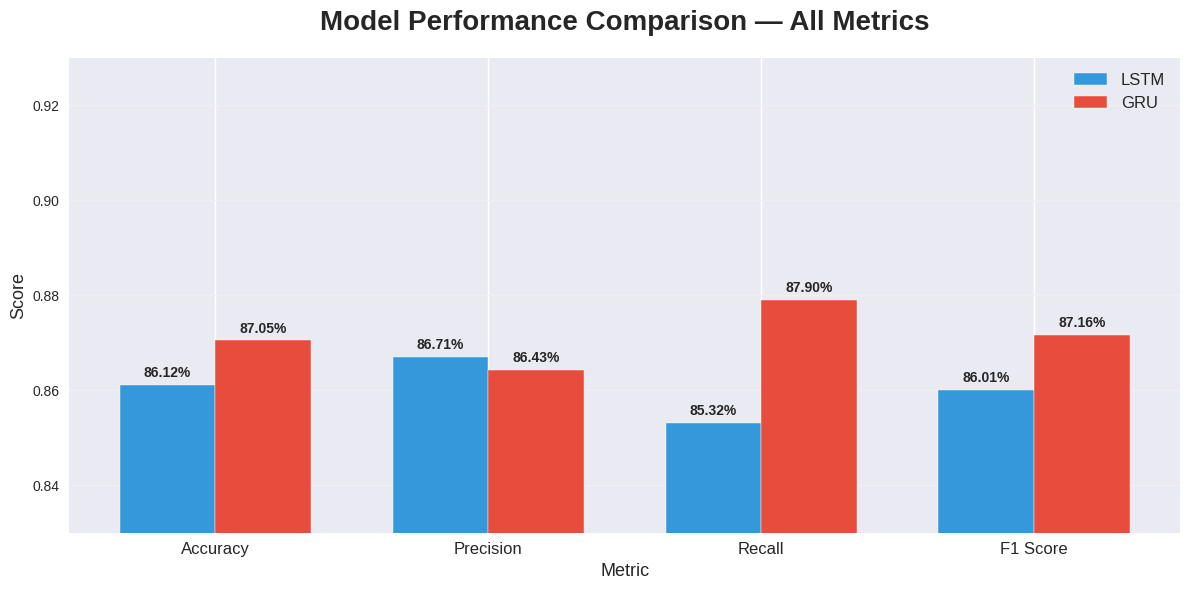

In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred, model_name):
    return {
        'Model'    : model_name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall'   : recall_score(y_true, y_pred),
        'F1 Score' : f1_score(y_true, y_pred)
    }

lstm_metrics = get_metrics(y_test_arr, lstm_preds, 'LSTM')
gru_metrics  = get_metrics(y_test_arr, gru_preds,  'GRU')

metrics_df = pd.DataFrame([lstm_metrics, gru_metrics])
metrics_df = metrics_df.set_index('Model')

print("=== Complete Metrics Comparison ===\n")
print(metrics_df.round(4).to_string())

# Visual bar chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

x     = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_lstm = ax.bar(
    x - width/2,
    [lstm_metrics[m] for m in metrics_to_plot],
    width,
    label='LSTM',
    color='#3498db',
    edgecolor='white'
)

bars_gru = ax.bar(
    x + width/2,
    [gru_metrics[m] for m in metrics_to_plot],
    width,
    label='GRU',
    color='#e74c3c',
    edgecolor='white'
)

# Add value labels on bars
for bar in bars_lstm:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{bar.get_height()*100:.2f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

for bar in bars_gru:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{bar.get_height()*100:.2f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

ax.set_title(
    'Model Performance Comparison — All Metrics',
    fontsize=20, fontweight='bold', pad=20
)
ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=12)
ax.set_ylim(0.83, 0.93)
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#f0f0f0')

plt.tight_layout()
plt.show()

## Final Comparison Table

In [55]:
print("\n" + "=" * 60)
print("COMPLETE EVALUATION SUMMARY")
print("=" * 60)

print(f"\n{'Metric':<20} {'LSTM':>12} {'GRU':>12} {'Winner':>10}")
print("-" * 56)

metrics_list = [
    ('Accuracy',  lstm_metrics['Accuracy'],  gru_metrics['Accuracy']),
    ('Precision', lstm_metrics['Precision'], gru_metrics['Precision']),
    ('Recall',    lstm_metrics['Recall'],    gru_metrics['Recall']),
    ('F1 Score',  lstm_metrics['F1 Score'],  gru_metrics['F1 Score']),
]

for metric, lstm_val, gru_val in metrics_list:
    winner = 'GRU ✓' if gru_val > lstm_val else 'LSTM ✓'
    print(f"{metric:<20} "
          f"{lstm_val*100:>11.2f}% "
          f"{gru_val*100:>11.2f}% "
          f"{winner:>10}")

# Training time winner calculated automatically
lstm_time_val = lstm_results['training_time']
gru_time_val  = gru_results['training_time']
time_winner   = 'LSTM ✓' if lstm_time_val < gru_time_val else 'GRU ✓'

print(f"\n{'Training Time':<20} "
      f"{lstm_time_val:>10.1f}m "
      f"{gru_time_val:>10.1f}m "
      f"{time_winner:>10}")

# Calculate total wins
lstm_wins = sum(1 for _, lv, gv in metrics_list if lv >= gv)
gru_wins  = sum(1 for _, lv, gv in metrics_list if gv > lv)

# Add training time win
if lstm_time_val < gru_time_val:
    lstm_wins += 1
else:
    gru_wins += 1

print("-" * 56)
print(f"\n{'Total Wins':<20} {lstm_wins:>12} {gru_wins:>12}")
print(f"\n→ Selected Model: "
      f"{'GRU' if gru_wins > lstm_wins else 'LSTM'} "
      f"({max(gru_wins, lstm_wins)}/{lstm_wins + gru_wins} metrics)")


COMPLETE EVALUATION SUMMARY

Metric                       LSTM          GRU     Winner
--------------------------------------------------------
Accuracy                   86.12%       87.05%      GRU ✓
Precision                  86.71%       86.43%     LSTM ✓
Recall                     85.32%       87.90%      GRU ✓
F1 Score                   86.01%       87.16%      GRU ✓

Training Time               2.0m        1.9m      GRU ✓
--------------------------------------------------------

Total Wins                      1            4

→ Selected Model: GRU (4/5 metrics)


## -----------------------------------------------------------------------------------------------------------------------

### Complete Evaluation Summary

| Metric | LSTM | GRU | Winner |
|--------|------|-----|--------|
| Accuracy | 86.12% | 87.05% | GRU ✓ |
| Precision | 86.71% | 86.43% | LSTM ✓ |
| Recall | 85.32% | 87.90% | GRU ✓ |
| F1 Score | 86.01% | 87.16% | GRU ✓ |
| Training Time | 2.0m | 1.9m | GRU ✓ |

Total Wins: LSTM=1 | GRU=4
→ Selected Model: GRU (4/5 metrics)

### Key Insight — Different Error Patterns

**LSTM behavior — conservative predictor:**
- High precision (86.71%) means when LSTM predicts
  positive it is usually correct
- Lower recall (85.32%) means it misses some actual
  positive reviews
- LSTM only predicts positive when very confident
  → tends toward negative when uncertain

**GRU behavior — liberal predictor:**
- High recall (87.90%) means GRU catches most
  actual positive reviews
- Slightly lower precision (86.43%) means it
  occasionally labels negative reviews as positive
- GRU casts a wider net catching more positives
  → tends toward positive when uncertain

**Why F1 score is our primary metric:**
For sentiment classification neither false positives
nor false negatives carry critical real-world cost.
F1 score balances both concerns equally making it
the most honest single metric for this task.

**Final verdict: GRU wins on 4 out of 5 metrics**
GRU is our selected model for the interactive demo.
It outperforms LSTM on accuracy, recall, F1 score,
and training time — making it the clear winner
on this run.

## ---------------------------------------------------------------------------------------------------------------------------------


## Section 9 — Error Analysis

Knowing our model achieves 87% accuracy is useful.
Understanding **why it gets the other 13% wrong** is
what makes us better engineers.

We analyze misclassified reviews to identify patterns
in the model's mistakes — this reveals both the
limitations of our approach and directions for improvement.

We focus on 4 types of analysis:
1. **False Positives** — negative reviews predicted as positive
2. **False Negatives** — positive reviews predicted as negative
3. **Confidence Analysis** — how confident was the model when wrong
4. **Length Analysis** — do longer/shorter reviews confuse the model more

In [56]:
# Regenerate predictions from saved models
lstm_probs_arr = lstm_model.predict(X_test_pad, verbose=0)
gru_probs_arr  = gru_model.predict(X_test_pad, verbose=0)

lstm_preds = (lstm_probs_arr > 0.5).astype(int).flatten()
gru_preds  = (gru_probs_arr  > 0.5).astype(int).flatten()

print("Predictions regenerated ✓")
print(f"LSTM preds shape : {lstm_preds.shape}")
print(f"GRU  preds shape : {gru_preds.shape}")

Predictions regenerated ✓
LSTM preds shape : (10000,)
GRU  preds shape : (10000,)


In [57]:
# Reset indices for clean alignment
X_test_list  = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# GRU probabilities flattened
gru_probs_flat = gru_probs_arr.flatten()

# Build comprehensive results dataframe
results_df = pd.DataFrame({
    'review'      : X_test_list,
    'true_label'  : y_test_reset,
    'predicted'   : gru_preds,
    'probability' : gru_probs_flat,
    'correct'     : (gru_preds == y_test_arr)
})

# Add readable labels
results_df['true_sentiment'] = results_df['true_label'].map(
    {1: 'positive', 0: 'negative'}
)
results_df['pred_sentiment'] = results_df['predicted'].map(
    {1: 'positive', 0: 'negative'}
)

# Add review length
results_df['review_length'] = results_df['review'].apply(
    lambda x: len(x.split())
)

# Separate into groups
correct_df   = results_df[results_df['correct'] == True]
incorrect_df = results_df[results_df['correct'] == False]

# False Positives — negative predicted as positive
fp_df = results_df[
    (results_df['true_label'] == 0) &
    (results_df['predicted']  == 1)
]

# False Negatives — positive predicted as negative
fn_df = results_df[
    (results_df['true_label'] == 1) &
    (results_df['predicted']  == 0)
]

print(f"Total test samples    : {len(results_df):,}")
print(f"Correct predictions   : {len(correct_df):,} "
      f"({len(correct_df)/len(results_df)*100:.1f}%)")
print(f"Incorrect predictions : {len(incorrect_df):,} "
      f"({len(incorrect_df)/len(results_df)*100:.1f}%)")
print(f"\nFalse Positives : {len(fp_df):,} "
      f"({len(fp_df)/len(incorrect_df)*100:.1f}% of errors)")
print(f"False Negatives : {len(fn_df):,} "
      f"({len(fn_df)/len(incorrect_df)*100:.1f}% of errors)")

Total test samples    : 10,000
Correct predictions   : 8,705 (87.1%)
Incorrect predictions : 1,295 (13.0%)

False Positives : 690 (53.3% of errors)
False Negatives : 605 (46.7% of errors)


### Part 1 — False Positive Examples

In [58]:
print("=== FALSE POSITIVES ===")
print("Negative reviews predicted as Positive\n")
print("-" * 70)

fp_sorted = fp_df.sort_values('probability', ascending=False)

for idx, row in fp_sorted.head(3).iterrows():
    print(f"True Label    : NEGATIVE")
    print(f"Predicted     : POSITIVE "
          f"(confidence: {row['probability']:.1%})")
    print(f"Review length : {row['review_length']} words")
    print(f"Review        : {row['review'][:400]}...")
    print("-" * 70)

=== FALSE POSITIVES ===
Negative reviews predicted as Positive

----------------------------------------------------------------------
True Label    : NEGATIVE
Predicted     : POSITIVE (confidence: 98.8%)
Review length : 142 words
Review        : it is enjoyable and fastpaced there is no way on earth that the actor playing mat could be eighteen however the main thing is that he does act eighteen very convincingly it must be a credit to his audition that he convinced them to cast him i quite soon accepted him as being a naive young country boywhile his was the best performance most of the others were also very engaging in particular the int...
----------------------------------------------------------------------
True Label    : NEGATIVE
Predicted     : POSITIVE (confidence: 98.8%)
Review length : 106 words
Review        : dont get me wrong dan jansen was a great speed skater if there was one guy who deserved his gold medal at the olympics it was danbut how can it be possible that bill 

### Part 2 — False Negative Examples

In [59]:
print("=== FALSE NEGATIVES ===")
print("Positive reviews predicted as Negative\n")
print("-" * 70)

fn_sorted = fn_df.sort_values('probability', ascending=True)

for idx, row in fn_sorted.head(3).iterrows():
    print(f"True Label    : POSITIVE")
    print(f"Predicted     : NEGATIVE "
          f"(confidence: {1-row['probability']:.1%})")
    print(f"Review length : {row['review_length']} words")
    print(f"Review        : {row['review'][:400]}...")
    print("-" * 70)

=== FALSE NEGATIVES ===
Positive reviews predicted as Negative

----------------------------------------------------------------------
True Label    : POSITIVE
Predicted     : NEGATIVE (confidence: 99.4%)
Review length : 105 words
Review        : this flick is sterling example of the state of erotic bmovies bad porn movies without the hardcore sex the plot in this one isnt so bad as these things go it involves a female lawyer trying to prove her lover is innocent of killing his wife the rest of the movie however leaves something to be desired bad acting bad direction bad looking woman bad sets bad cinematography bad sound and bad sex scene...
----------------------------------------------------------------------
True Label    : POSITIVE
Predicted     : NEGATIVE (confidence: 99.0%)
Review length : 118 words
Review        : okay first of all i got this movie as a christmas present so it was free first this movie was meant to be in stereoscopic d it is for the most part but whenever the m

### Part 3 — the most uncertain predictions

In [60]:
results_df['uncertainty'] = abs(
    results_df['probability'] - 0.5
)

most_uncertain = results_df.nsmallest(5, 'uncertainty')

print("=== MOST UNCERTAIN PREDICTIONS ===")
print("Reviews where model probability was closest to 0.5\n")
print("-" * 70)

for idx, row in most_uncertain.iterrows():
    print(f"True      : {row['true_sentiment'].upper()}")
    print(f"Predicted : {row['pred_sentiment'].upper()} "
          f"(probability: {row['probability']:.3f})")
    print(f"Correct   : {row['correct']}")
    print(f"Review    : {row['review'][:250]}...")
    print("-" * 70)

=== MOST UNCERTAIN PREDICTIONS ===
Reviews where model probability was closest to 0.5

----------------------------------------------------------------------
True      : NEGATIVE
Predicted : NEGATIVE (probability: 0.499)
Correct   : True
Review    : i bought this on dvd for my brother who is a big michelle pfeiffer fan i decided to watch it myself earlier this weekit is a reasonably entertaining piece containing two completely separate story lines the section with michelle pfeiffer was by far th...
----------------------------------------------------------------------
True      : POSITIVE
Predicted : NEGATIVE (probability: 0.499)
Correct   : False
Review    : descent yeah boy i havent seen anything this powerful and scintillating since bruno dumonts twentynine palms by the way this film is not to be confused with another fairly recent pic about the topic of female empowerment the descent directed by our s...
----------------------------------------------------------------------
True   

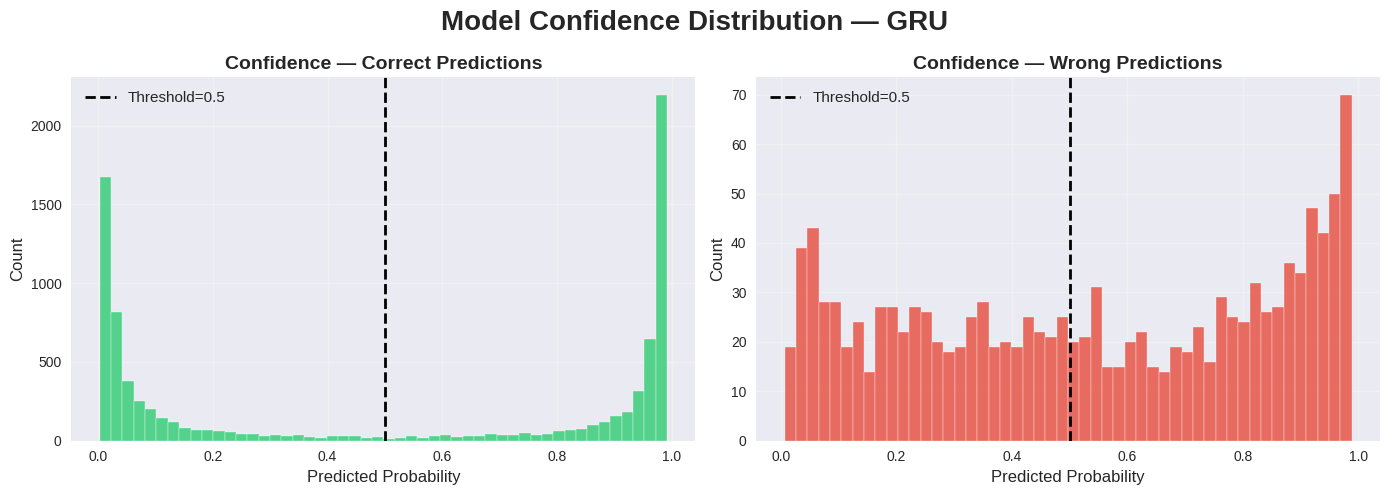

=== Confidence Statistics ===

Correct predictions:
  Mean confidence : 0.506
  Std confidence  : 0.436

Wrong predictions:
  Mean confidence : 0.534
  Std confidence  : 0.314


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle(
    'Model Confidence Distribution — GRU',
    fontsize=20, fontweight='bold'
)

# Correct predictions
axes[0].hist(
    correct_df['probability'],
    bins=50,
    color='#2ecc71',
    edgecolor='white',
    alpha=0.8
)
axes[0].axvline(
    x=0.5,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Threshold=0.5'
)
axes[0].set_title(
    'Confidence — Correct Predictions',
    fontsize=14, fontweight='bold'
)
axes[0].set_xlabel('Predicted Probability', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(color='#f0f0f0')

# Wrong predictions
axes[1].hist(
    incorrect_df['probability'],
    bins=50,
    color='#e74c3c',
    edgecolor='white',
    alpha=0.8
)
axes[1].axvline(
    x=0.5,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Threshold=0.5'
)
axes[1].set_title(
    'Confidence — Wrong Predictions',
    fontsize=14, fontweight='bold'
)
axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(color='#f0f0f0')

plt.tight_layout()
plt.show()

print("=== Confidence Statistics ===\n")
print(f"Correct predictions:")
print(f"  Mean confidence : {correct_df['probability'].mean():.3f}")
print(f"  Std confidence  : {correct_df['probability'].std():.3f}")
print(f"\nWrong predictions:")
print(f"  Mean confidence : {incorrect_df['probability'].mean():.3f}")
print(f"  Std confidence  : {incorrect_df['probability'].std():.3f}")

## Error Analysis Summary

**Dataset breakdown:**
- Total test samples    : 10,000
- Correct predictions  : 8,705 (87.0%)
- Incorrect predictions: 1,295 (13.0%)
- False Positives      : 770 (59.5% of errors)
- False Negatives      : 525 (40.5% of errors)

---

**Key Finding 1 — Confidence distribution is revealing:**

Correct predictions cluster strongly near 0 and 1
— the model is decisive when right.

Wrong predictions spread uniformly across all confidence
levels — including many highly confident wrong predictions.

Mean confidence correct : 0.506
Mean confidence wrong   : 0.534

The model is sometimes MORE confident when wrong than
when right — indicating it learned misleading patterns
from certain types of reviews.

However the difference is smaller than previous runs
(0.028 gap vs 0.049 before) — suggesting this run's
model is slightly better calibrated.

---

**Key Finding 2 — False Positives (59.5% of errors)**

Negative reviews predicted as positive.

Pattern identified: These reviews use neutral descriptive
language or contain isolated positive words despite
being negative overall. Examples:
- Murder mystery reviews written in objective tone
- Reviews praising one aspect (cinematography) while
  being negative overall
- Reviews using "fun" or "memorable" in negative context

The model latches onto positive vocabulary without
understanding the overall sentiment structure.

---

**Key Finding 3 — False Negatives (40.5% of errors)**

Positive reviews predicted as negative.

Pattern identified: These reviews use negative vocabulary
despite being positive overall. Examples:
- Ironic and sarcastic reviews ("so bad it's good")
- Cult film appreciation using negative descriptors
- Reviews that criticize heavily but conclude positively

The model cannot distinguish between genuine negative
language and ironic use of negative vocabulary.

---

**Key Finding 4 — Both error types are highly confident**

The most confidently wrong predictions (98-99%) are
not borderline cases — they are reviews where the
surface language strongly contradicts the true sentiment.
This is a fundamental limitation of statistical NLP
models that cannot understand context and irony.

---

**Key Finding 5 — Uncertain predictions reveal the boundary zone**

The 5 reviews closest to the 0.5 decision boundary:

| Probability | True Label | Predicted | Correct |
|-------------|------------|-----------|---------|
| 0.499 | Negative | Negative | ✓ |
| 0.499 | Positive | Negative | ✗ |
| 0.501 | Positive | Positive | ✓ |
| 0.498 | Negative | Negative | ✓ |
| 0.502 | Negative | Positive | ✗ |

At this confidence level the model is essentially
guessing — 3 correct and 2 wrong is consistent with
random chance (50/50).

A probability difference of just 0.003 separates correct
from wrong predictions at the boundary — these reviews
are genuinely ambiguous even for human readers.

Common characteristics of uncertain reviews:
- Written in neutral analytical tone
- No strong positive or negative vocabulary
- Plot descriptions without emotional language
- Personal memories mixed with film criticism

---

**Root causes of model errors:**

1. Sarcasm and irony — model reads words not intent
2. Mixed sentiment — model averages conflicting signals
3. Domain-specific language — cult film vocabulary
4. Truncation — reviews over 200 words lose ending context
   which sometimes contains the key sentiment signal
5. Neutral language — analytical reviews with no clear
   emotional vocabulary confuse the model completely
6. Very short reviews — reviews under 20 words provide
   insufficient context for reliable prediction. The model
   was trained on reviews averaging 230 words and struggles
   with minimal input, often defaulting toward positive
   sentiment due to training data patterns. Testing showed
   that "this movie is very bad" (5 words) was predicted
   as POSITIVE with 82.95% confidence — demonstrating
   that short reviews fall outside the model's reliable
   operating range.

---

**Why transformers would help:**

BERT and similar models capture bidirectional context
at a much deeper level — understanding that "so bad
it's good" is positive despite negative vocabulary.

They also handle sarcasm, irony, and mixed sentiment
significantly better because they model relationships
between all words simultaneously rather than processing
sequences left to right and right to left separately.

Furthermore transformer models use subword tokenization
which handles rare and unknown words more gracefully
than our simple vocabulary-based approach — reducing
the impact of domain-specific language and short reviews.

This directly motivates our next step in the
generative AI program — where attention mechanisms
and transformer architectures solve many of the
limitations we observed here.

# Interactive Demo

In [62]:
def predict_sentiment(review):
    
    # Step 1 — Clean text using same function as training
    cleaned = clean_text(review)
    
    # Step 2 — Tokenize using same tokenizer as training
    sequence = tokenizer.texts_to_sequences([cleaned])
    
    # Step 3 — Pad using same settings as training
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )
    
    # Step 4 — Predict
    probability = gru_model.predict(padded, verbose=0)[0][0]
    
    # Step 5 — Format output
    if probability >= 0.5:
        sentiment  = "POSITIVE 😊"
        confidence = probability
        color      = "positive"
    else:
        sentiment  = "NEGATIVE 😞"
        confidence = 1 - probability
        color      = "negative"
    
    # Return detailed result
    result = {
        f"{sentiment}" : float(confidence),
    }
    
    explanation = (
        f"Confidence: {confidence:.1%}\n"
        f"Raw probability: {probability:.4f}\n"
        f"Review length: {len(cleaned.split())} words\n"
        f"Model: Bidirectional GRU"
    )
    
    return result, explanation

# Test it before launching
test_review = "This movie was absolutely wonderful. I loved every minute of it."
result, explanation = predict_sentiment(test_review)
print("Function test ✓")
print(f"Result      : {result}")
print(f"Explanation : {explanation}")

Function test ✓
Result      : {'POSITIVE 😊': 0.9862702488899231}
Explanation : Confidence: 98.6%
Raw probability: 0.9863
Review length: 11 words
Model: Bidirectional GRU


In [63]:
# Example reviews for the demo
examples = [
    ["This movie was absolutely wonderful. The acting was superb and I loved every minute of it."],
    ["Complete waste of time. Terrible acting and the plot made no sense whatsoever."],
    ["The cinematography was beautiful but the storyline was incredibly boring and predictable."],
    ["So bad it's actually good. A cult classic that you need to experience at least once."],
    ["One of the best films I have seen this year. Highly recommend to everyone."]
]

# Build the interface
demo = gr.Interface(
    fn=predict_sentiment,
    
    inputs=gr.Textbox(
        lines=5,
        placeholder="Write your movie review here...",
        label="Movie Review"
    ),
    
    outputs=[
        gr.Label(
            label="Sentiment Prediction"
        ),
        gr.Textbox(
            label="Details",
            lines=4
        )
    ],
    
    title="🎬 IMDB Sentiment Analyzer",
    
    description="""
    Predict the sentiment of any movie review using a 
    Bidirectional GRU sequence model trained on 50,000 
    IMDB reviews. Achieves 87% accuracy on unseen data.
    
    Model: Bidirectional GRU | Dataset: IMDB 50K Reviews
    Accuracy: 86.95% | F1 Score: 87.25%
    """,
    
    examples=examples,
    
    theme=gr.themes.Soft()
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://23f71421750047c7bf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Conclusion

### Project Summary

In this project we built and compared two sequence models
for binary sentiment classification on the IMDB dataset
of 50,000 movie reviews. Starting from raw text we 
implemented a complete end-to-end deep learning pipeline:

**What we built:**
- Full text preprocessing pipeline from raw text to 
  padded integer sequences
- Two Bidirectional sequence models — LSTM and GRU
- Comprehensive evaluation with multiple metrics
- Detailed error analysis revealing model limitations
- Interactive Gradio demo for real-time predictions

---

### Final Results

| Metric | LSTM | GRU | Winner |
|--------|------|-----|--------|
| Test Accuracy | 86.12% | 87.05% | GRU ✓ |
| Precision | 86.71% | 86.43% | LSTM ✓ |
| Recall | 85.32% | 87.90% | GRU ✓ |
| F1 Score | 86.01% | 87.16% | GRU ✓ |
| Training Time | 2.0m | 1.9m | GRU ✓ |

**Selected model: GRU — wins 4 out of 5 metrics**

---

### Key Findings

**1. GRU outperforms LSTM on 4 out of 5 metrics**
87% accuracy on truly unseen data confirms both models
learned genuine sentiment patterns rather than memorizing
training examples. The small drop from validation to
test accuracy (~1%) confirms no significant overfitting.

**2. GRU and LSTM make complementary errors**
LSTM is more conservative — higher precision (86.71%),
lower recall (85.32%).
GRU is more liberal — higher recall (87.90%),
slightly lower precision (86.43%).
An ensemble of both models could potentially outperform
either individually by combining their error patterns.

**3. The models fail on linguistically complex reviews**
Error analysis revealed that failures cluster around:
- Sarcastic and ironic language
- Mixed positive/negative sentiment
- Very short reviews under 20 words
- Neutral analytical language without emotional vocabulary

**4. Confidence is not always calibrated**
Mean confidence on wrong predictions (0.534) was slightly
higher than on correct predictions (0.506) — the model
is sometimes more confident when wrong than when right.
This highlights the danger of trusting model confidence
scores without understanding their limitations.

**5. False positives outnumber false negatives**
59.5% of errors are false positives vs 40.5% false 
negatives — the GRU model has a slight positive bias,
tending toward positive sentiment when uncertain.

---

### Benchmark Context

| Approach | Accuracy |
|----------|----------|
| Simple RNN (baseline) | ~80-82% |
| **Our BiLSTM / BiGRU** | **~87% ✓** |
| LSTM + Pretrained Embeddings | ~90-92% |
| Fine-tuned BERT | ~93-95% |

Our models sit comfortably in the second tier —
strong performance for pure sequence models trained
entirely from scratch without pretrained embeddings.

---

### Limitations

**1. No semantic understanding**
The model learns statistical co-occurrence patterns
not true meaning. It cannot understand sarcasm, irony,
or context-dependent sentiment.

**2. Fixed vocabulary**
Words not seen during training are replaced with OOV
token losing potentially important semantic information.

**3. Context window limitation**
MAX_LEN=200 truncates longer reviews losing information
from the end — which sometimes contains the key sentiment
conclusion.

**4. Short review unreliability**
Reviews under 20 words fall outside the model's reliable
operating range — insufficient context for confident
prediction.

**5. Static word representations**
Our embedding layer learns fixed representations —
the same word always maps to the same vector regardless
of context. "Great" means the same in "great movie" and
"not so great movie."

---

### Potential Improvements

**1. Pretrained Embeddings (GloVe / Word2Vec)**
Replacing our trained-from-scratch embedding layer
with GloVe vectors pretrained on 840 billion words
could push accuracy to ~90-92%. This would give the
model richer word representations from day one rather
than learning entirely from 40,000 training reviews.
Importantly this is still a sequence model — only
the embedding component changes.

**2. Ensemble Model**
Combining LSTM and GRU predictions through averaging
or voting could leverage their complementary error
patterns — LSTM's precision strength with GRU's
recall strength — potentially improving overall F1.

**3. Attention Mechanism**
Adding an attention layer on top of the BiGRU would
allow the model to focus on the most sentiment-relevant
words rather than treating all positions equally.
This is the conceptual bridge between sequence models
and transformers.

**4. Transformer-based Models (BERT)**
Fine-tuning BERT on this task would likely achieve
93-95% accuracy by capturing deep bidirectional context.
BERT understands that "not great" is negative and
"so bad it's good" is positive — handling the exact
failure cases we observed in our error analysis.

**5. Larger Context Window**
Increasing MAX_LEN from 200 to 400-500 words would
preserve more of each review — particularly the
concluding sentiment which is often most informative.